In [29]:
import os, re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from scipy.sparse import hstack

CSV_PATH = "../outputs/ocr/structured_transactions.csv"
OUT_DIR  = "../outputs/eda/"
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(CSV_PATH, parse_dates=["date"])
for c in ["debit","credit","balance"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
print("Rows loaded:", len(df))
display(df.head(5))


Rows loaded: 191


,date,description,debit,credit,balance,source_image
0,2023-08-08,OO ESSN ot,NaN,350.0,10804.33,2023_August_Statement (6)_page_2_table_1.png
1,2023-08-09,VANTAGE TOYOTA CD 0523,288.0,NaN,10516.33,2023_August_Statement (6)_page_2_table_1.png
2,2023-08-10,HMRC E VAT 0000148023,960.0,NaN,9556.33,2023_August_Statement (6)_page_2_table_1.png
3,2023-08-10,ee NSE,NaN,832.0,10388.33,2023_August_Statement (6)_page_2_table_1.png
4,2023-08-10,$Oo900001179221216 RADIO,500.0,NaN,9888.33,2023_August_Statement (6)_page_2_table_1.png


In [30]:
def clean_text(s: str) -> str:
    if not isinstance(s, str): return ""
    s = re.sub(r"\s+", " ", s).strip()
    # keep letters, numbers and a few separators
    s = re.sub(r"[^\w\s\-/&.,]", "", s)
    return s

df["desc_clean"] = df["description"].astype(str).apply(clean_text)
df["desc_upper"] = df["desc_clean"].str.upper()

# Hand-crafted merchant lexicon (expand if you see more in your data)
MERCHANT_PATTERNS = {
    # grocers
    "TESCO": r"\bTESCO\b",
    "SAINSBURY": r"\bSAINS?BURY",
    "MORRISONS": r"\bMORRISONS?\b",
    "ASDA": r"\bASDA\b",
    "ALDI": r"\bALDI\b",
    "LIDL": r"\bLIDL\b",
    # ecommerce / online
    "AMAZON": r"\bAMAZON\b",
    "EBAY": r"\bE\s?BAY\b|\bEBAY\b",
    "PAYPAL": r"\bPAYPAL\b",
    "GOOGLE": r"\bGOOGLE\b",
    "APPLE": r"\bAPPLE\b",
    # transport / mobility
    "TFL": r"\bTFL\b|\bTRNSPRT\b|TRAVELCARD|OYSTER",
    "UBER": r"\bUBER\b",
    "TRAINLINE": r"\bTRAINLINE\b",
    # fuel
    "SHELL": r"\bSHELL\b",
    "BP": r"\bBP\b",
    # telecoms
    "VODAFONE": r"\bVODAFONE\b",
    "O2": r"\bO2\b",
    "EE": r"\bEE\b",
    "THREE": r"\b3UK\b|\bTHREE\b",
    # govt / finance
    "HMRC": r"\bHMRC\b",
    "DVLA": r"\bDVLA\b",
    "COUNCIL": r"\bCOUNCIL\b|BOROUGH|DISTRICT",
    # food & coffee chains
    "MCDONALDS": r"MCDONA?LDS",
    "STARBUCKS": r"STARBUCKS",
    "COSTA": r"\bCOSTA\b",
    "PRET": r"\bPRET\b",
    "SUBWAY": r"\bSUBWAY\b",
    # misc from your data
    "REDBRIDGE": r"\bREDBRIDGE\b",
    "PARKS": r"\bPARKS?\b",
    "TOYOTA": r"\bTOYOTA\b",
    "SHELL OIL": r"SHELL\s*OIL",
    "BEDUL": r"\bBEDUL\b",  # present in your OCR; keep as-is
}

compiled = {k: re.compile(v) for k, v in MERCHANT_PATTERNS.items()}

def merchant_label(desc_upper: str) -> str:
    for name, pat in compiled.items():
        if pat.search(desc_upper):
            return name
    # fallback: try to get a reasonable token as label
    tokens = [t for t in re.split(r"[^\w]+", desc_upper) if len(t) >= 3]
    if not tokens:
        return "OTHER"
    # Prefer longer tokens that are not purely numeric
    tokens = [t for t in tokens if not t.isdigit()]
    if not tokens:
        return "OTHER"
    # choose the most frequent candidate across dataset (helps consistency)
    return tokens[0]

df["merchant"] = df["desc_upper"].apply(merchant_label)
print("Top labels:\n", df["merchant"].value_counts().head(20))
display(df[["date","description","merchant"]].head(10))


Top labels:
 merchant
EBAY              15
EE                11
EEE                8
OTHER              7
SBAY               4
MERCHANT           4
RIGHTWAY           4
AMZNMKTPLACE       4
OTT                3
APPLE              3
TESCO              3
TOYOTA             3
EET                3
NO_DESCRIPTION     3
AMAZON             3
OTE                2
GARAGE             2
PREMIER            2
VANTAGE            2
SERVICE            2
Name: count, dtype: int64


,date,description,merchant
0,2023-08-08,OO ESSN ot,ESSN
1,2023-08-09,VANTAGE TOYOTA CD 0523,TOYOTA
2,2023-08-10,HMRC E VAT 0000148023,HMRC
3,2023-08-10,ee NSE,EE
4,2023-08-10,$Oo900001179221216 RADIO,OO900001179221216
5,2023-08-10,eBay 0*19-10389-11CD 0515,EBAY
6,2023-08-10,NO a pgoooet 186200789,PGOOOET
7,2023-08-11,Oe ESS anaat,ESS
8,2023-08-11,Hac EBK *Q624VSTSG2 CD,HAC
9,2023-08-14,TESCOEFS 3888 CD 0528,TESCOEFS


In [31]:
MIN_PER_CLASS = 8  # adjust if you want more/less classes

vc = df["merchant"].value_counts()
valid = vc[vc >= MIN_PER_CLASS].index
dfm = df[df["merchant"].isin(valid)].copy()

print("Classes kept:", len(valid), "| Rows:", len(dfm))
print(dfm["merchant"].value_counts().head(20))


Classes kept: 3 | Rows: 34
merchant
EBAY    15
EE      11
EEE      8
Name: count, dtype: int64


In [32]:
# text features
vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1,2), min_df=2)
X_text = vectorizer.fit_transform(dfm["desc_clean"])

# numeric addons (optional; helps for some merchants)
X_num = dfm[["debit","credit","balance"]].fillna(0).values
X = hstack([X_text, X_num])

y = dfm["merchant"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape, "| Classes:", len(np.unique(y)))


Train: (25, 29)  Test: (9, 29) | Classes: 3


In [33]:
models = {
    "LinearSVC": LinearSVC(random_state=42),
    "LogReg": LogisticRegression(max_iter=2000, class_weight="balanced", n_jobs=None),
    "MultinomialNB": MultinomialNB(),  # works well with TF-IDF text
    "RandomForest": RandomForestClassifier(n_estimators=400, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
}

results, y_hat = {}, {}

for name, model in models.items():
    print(f"\n▶ Training {name} ...")
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    y_hat[name] = pred
    acc = accuracy_score(y_test, pred)
    results[name] = acc
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, pred, zero_division=0))



▶ Training LinearSVC ...
Accuracy: 0.5556
              precision    recall  f1-score   support

        EBAY       0.67      1.00      0.80         4
          EE       0.50      0.33      0.40         3
         EEE       0.00      0.00      0.00         2

    accuracy                           0.56         9
   macro avg       0.39      0.44      0.40         9
weighted avg       0.46      0.56      0.49         9


▶ Training LogReg ...


c:\Users\admin\OneDrive\Desktop\Dissertation 1\code\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\admin\OneDrive\Desktop\Dissertation 1\code\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.7778
              precision    recall  f1-score   support

        EBAY       1.00      1.00      1.00         4
          EE       0.67      0.67      0.67         3
         EEE       0.50      0.50      0.50         2

    accuracy                           0.78         9
   macro avg       0.72      0.72      0.72         9
weighted avg       0.78      0.78      0.78         9


▶ Training MultinomialNB ...
Accuracy: 0.7778
              precision    recall  f1-score   support

        EBAY       1.00      1.00      1.00         4
          EE       0.60      1.00      0.75         3
         EEE       0.00      0.00      0.00         2

    accuracy                           0.78         9
   macro avg       0.53      0.67      0.58         9
weighted avg       0.64      0.78      0.69         9


▶ Training RandomForest ...
Accuracy: 0.8889
              precision    recall  f1-score   support

        EBAY       1.00      1.00      1.00         4
          EE       

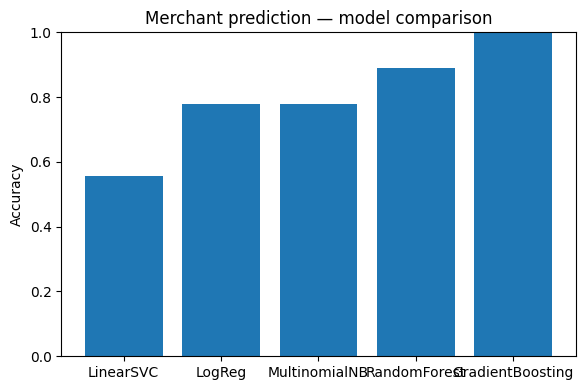

In [34]:
plt.figure(figsize=(6,4))
plt.bar(list(results.keys()), list(results.values()))
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Merchant prediction — model comparison")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "merchant_model_accuracy.png"), dpi=160)
plt.show()


Best model: GradientBoosting | Accuracy: 1.0


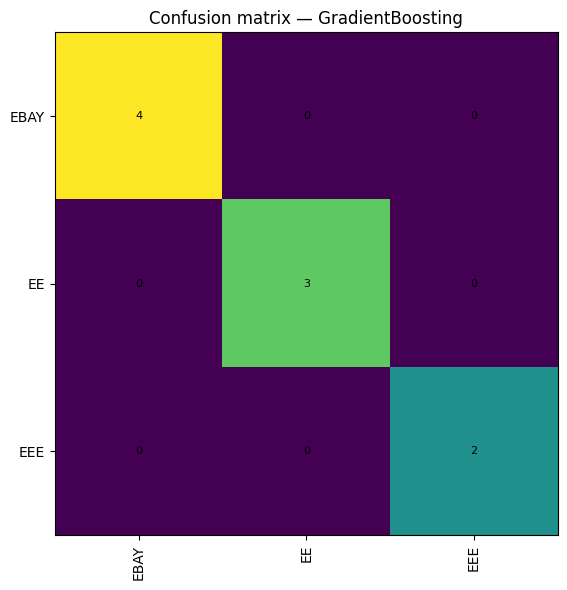

In [35]:
best = max(results, key=results.get)
print("Best model:", best, "| Accuracy:", results[best])

labels = sorted(np.unique(y_test))
cm = confusion_matrix(y_test, y_hat[best], labels=labels)

plt.figure(figsize=(max(6, 0.35*len(labels)+2), max(6, 0.35*len(labels)+2)))
plt.imshow(cm, interpolation='nearest')
plt.title(f"Confusion matrix — {best}")
plt.xticks(range(len(labels)), labels, rotation=90)
plt.yticks(range(len(labels)), labels)
for (i,j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha='center', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f"merchant_confusion_{best}.png"), dpi=160)
plt.show()


In [36]:
def show_top_terms(model, vectorizer, labels, k=10, save_name=None):
    if not hasattr(model, "coef_"):
        print("Top-terms only for linear models (LinearSVC/LogReg).")
        return
    feature_names = np.array(list(vectorizer.get_feature_names_out()) + ["debit","credit","balance"])
    # last 3 are numeric; focus on text
    text_mask = np.arange(len(feature_names)) < len(vectorizer.get_feature_names_out())

    plt.figure(figsize=(10, 0.5*len(labels)))
    rows = []
    for idx, label in enumerate(labels):
        coefs = model.coef_[idx]
        top_idx = np.argsort(coefs[text_mask])[-k:][::-1]
        terms = feature_names[top_idx]
        rows.append((label, ", ".join(terms)))
    df_terms = pd.DataFrame(rows, columns=["merchant","top_terms"])
    display(df_terms.head(20))
    if save_name:
        df_terms.to_csv(os.path.join(OUT_DIR, save_name), index=False)

# Example: run this after training to inspect best linear model:
linear_model = models["LinearSVC"] if "LinearSVC" in models else models["LogReg"]
linear_model.fit(X_train, y_train)
show_top_terms(linear_model, vectorizer, sorted(np.unique(y_train)),
               k=10, save_name="merchant_top_terms.csv")


c:\Users\admin\OneDrive\Desktop\Dissertation 1\code\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,merchant,top_terms
0,EBAY,"ebay, 0523, 0515, 014, ebay 014, 11cd, 11cd 05..."
1,EE,"ee, ee eee, ee mt, mt, 10313, ebay 002, 002 10..."
2,EEE,"oe eee, oe, eee, ot, 90cd 0531, 90cd, 10313, e..."


<Figure size 1000x150 with 0 Axes>